# 08 — Half-Sibling Analysis

Can we utilise the 607 second-degree (putative half-sibling) pairs for CKMR?

Four tests:
1. **Spatial validation** — do 2nd-degree pairs cluster geographically?
2. **Mixture modelling** — separate real HS from inflated unrelated background
3. **Network analysis** — do 2nd-degree pairs form family cliques?
4. **HS-CKMR estimate** — population size from half-siblings

**Inputs**: `data/kin_pairs.csv`, `data/geno_dropout_filtered.csv`, `data/master_metadata.csv`
**Output**: `results/halfsib_analysis.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, pearsonr, mannwhitneyu
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
kin_pairs = pd.read_csv('../data/kin_pairs.csv')
meta = pd.read_csv('../data/master_metadata.csv')
geno = pd.read_csv('../data/geno_dropout_filtered.csv', index_col=0)

print(f'Kin pairs: {len(kin_pairs)}')
print(kin_pairs['relationship'].value_counts())
print(f'\nGenotypes: {geno.shape[0]:,} markers x {geno.shape[1]:,} samples')

Kin pairs: 2153
relationship
3rd    1542
2nd     607
FS        4
Name: count, dtype: int64

Genotypes: 11,357 markers x 836 samples


In [3]:
# Reconstruct full kinship distribution from the KING matrix
# We need pairwise kinship for ALL pairs (not just > 0.044) for mixture modelling
print('Recomputing full pairwise kinship...')

G = geno.values.T.astype(float)  # samples x markers
n_samples = G.shape[0]
sample_ids = geno.columns.tolist()

G_masked = np.where(np.isfinite(G), G, -1)
is_het = (G_masked == 1).astype(np.float32)
is_hom_ref = (G_masked == 0).astype(np.float32)
is_hom_alt = (G_masked == 2).astype(np.float32)

n_het_per_sample = is_het.sum(axis=1)
N_both_het = is_het @ is_het.T
N_ibs0 = is_hom_ref @ is_hom_alt.T + is_hom_alt @ is_hom_ref.T

denom = n_het_per_sample[:, None] + n_het_per_sample[None, :]
with np.errstate(divide='ignore', invalid='ignore'):
    kinship_full = (N_both_het - 2 * N_ibs0) / denom

# Extract upper triangle
iu = np.triu_indices(n_samples, k=1)
kin_vals = kinship_full[iu]
valid = np.isfinite(kin_vals)
kin_valid = kin_vals[valid]

print(f'Total pairs: {len(kin_valid):,}')
print(f'Kinship range: {kin_valid.min():.4f} to {kin_valid.max():.4f}')
print(f'Mean: {kin_valid.mean():.4f}, Median: {np.median(kin_valid):.4f}')

Recomputing full pairwise kinship...


Total pairs: 349,030
Kinship range: -0.7938 to 0.3096
Mean: -0.1132, Median: -0.0993


## 1. Spatial validation of 2nd-degree pairs

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

gps = meta[['sample_id', 'latitude', 'longitude']].drop_duplicates(subset='sample_id').dropna()
gps_dict = gps.set_index('sample_id')[['latitude', 'longitude']].to_dict('index')

# Compute distances for all kin pairs
dists = []
for _, row in kin_pairs.iterrows():
    s1, s2 = row['sample_1'], row['sample_2']
    if s1 in gps_dict and s2 in gps_dict:
        dists.append(haversine(gps_dict[s1]['latitude'], gps_dict[s1]['longitude'],
                               gps_dict[s2]['latitude'], gps_dict[s2]['longitude']))
    else:
        dists.append(np.nan)
kin_pairs['distance_km'] = dists

# Random pair distances (null)
rng = np.random.default_rng(42)
gps_arr = gps[['latitude', 'longitude']].values
rand_dists = []
for _ in range(50000):
    i, j = rng.choice(len(gps_arr), 2, replace=False)
    rand_dists.append(haversine(gps_arr[i, 0], gps_arr[i, 1], gps_arr[j, 0], gps_arr[j, 1]))
rand_dists = np.array(rand_dists)

# Compare distributions
for rel in ['FS', '2nd', '3rd']:
    subset = kin_pairs[kin_pairs['relationship'] == rel]['distance_km'].dropna()
    if len(subset) > 1:
        stat, pval = mannwhitneyu(subset, rand_dists, alternative='less')
        print(f'{rel} (n={len(subset)}): mean={subset.mean():.2f} km, median={subset.median():.2f} km, '
              f'vs random mean={rand_dists.mean():.2f} km | Mann-Whitney p={pval:.2e}')

FS (n=4): mean=1.04 km, median=0.99 km, vs random mean=2.02 km | Mann-Whitney p=3.16e-02
2nd (n=606): mean=2.05 km, median=2.01 km, vs random mean=2.02 km | Mann-Whitney p=5.30e-01
3rd (n=1538): mean=1.99 km, median=2.12 km, vs random mean=2.02 km | Mann-Whitney p=3.02e-01


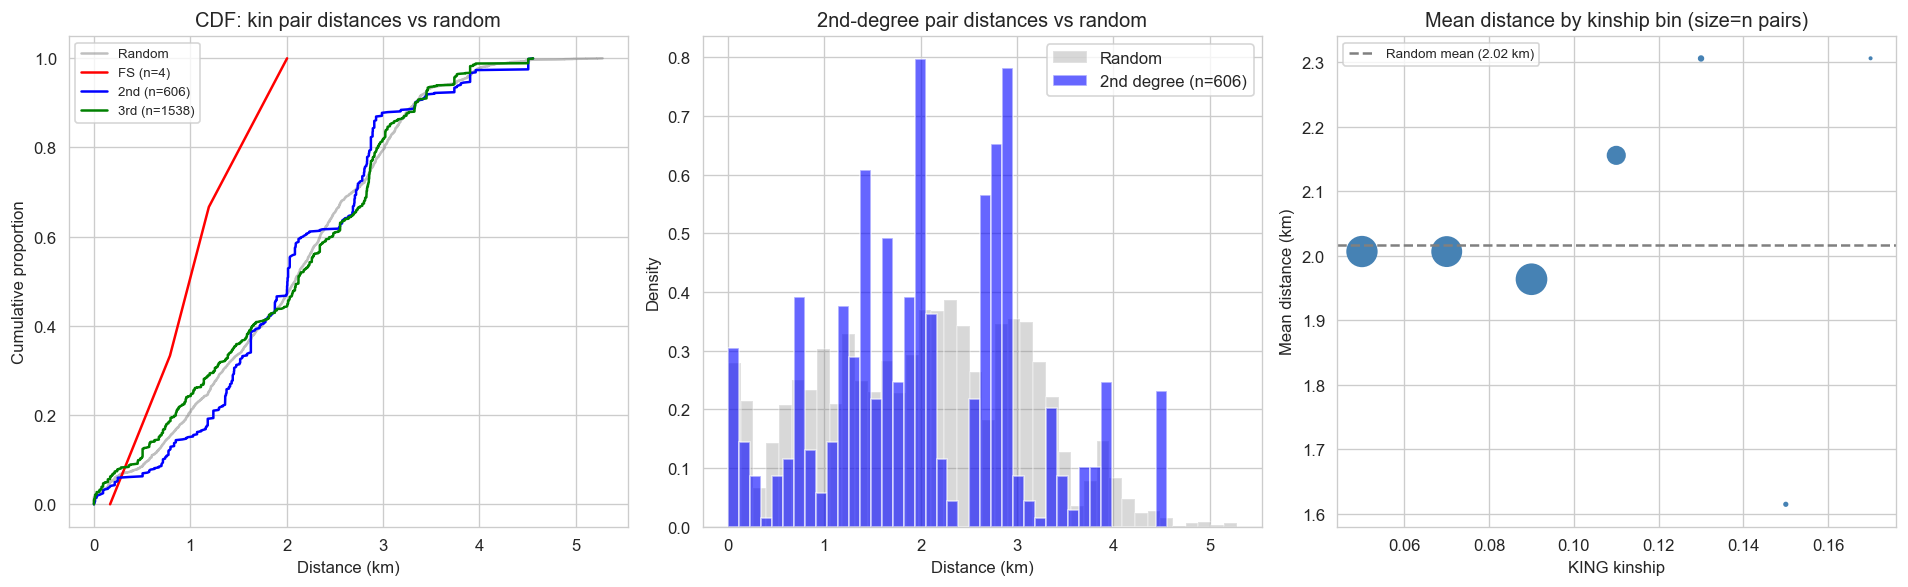

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'FS': 'red', '2nd': 'blue', '3rd': 'green'}

# CDF comparison
ax = axes[0]
rand_sorted = np.sort(rand_dists)
ax.plot(rand_sorted, np.linspace(0, 1, len(rand_sorted)), c='grey', alpha=0.5, label='Random')
for rel in ['FS', '2nd', '3rd']:
    subset = kin_pairs[kin_pairs['relationship'] == rel]['distance_km'].dropna().sort_values()
    if len(subset) > 1:
        ax.plot(subset.values, np.linspace(0, 1, len(subset)), c=colors[rel], label=f'{rel} (n={len(subset)})')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Cumulative proportion')
ax.set_title('CDF: kin pair distances vs random')
ax.legend(fontsize=8)

# Histogram comparison for 2nd degree
ax = axes[1]
second = kin_pairs[kin_pairs['relationship'] == '2nd']['distance_km'].dropna()
ax.hist(rand_dists, bins=40, density=True, alpha=0.3, color='grey', label='Random')
ax.hist(second, bins=40, density=True, alpha=0.6, color='blue', label=f'2nd degree (n={len(second)})')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Density')
ax.set_title('2nd-degree pair distances vs random')
ax.legend()

# Mean distance by kinship bin
ax = axes[2]
valid_pairs = kin_pairs.dropna(subset=['distance_km'])
bins = np.arange(0.04, 0.32, 0.02)
bin_means = []
bin_centers = []
bin_ns = []
for i in range(len(bins) - 1):
    mask = (valid_pairs['kinship'] >= bins[i]) & (valid_pairs['kinship'] < bins[i+1])
    subset = valid_pairs[mask]['distance_km']
    if len(subset) > 2:
        bin_means.append(subset.mean())
        bin_centers.append((bins[i] + bins[i+1]) / 2)
        bin_ns.append(len(subset))

ax.scatter(bin_centers, bin_means, s=[n/2 for n in bin_ns], c='steelblue')
ax.axhline(rand_dists.mean(), color='grey', ls='--', label=f'Random mean ({rand_dists.mean():.2f} km)')
ax.set_xlabel('KING kinship')
ax.set_ylabel('Mean distance (km)')
ax.set_title('Mean distance by kinship bin (size=n pairs)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/fig_halfsib_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Mixture modelling of kinship distribution

Fit a Gaussian mixture to the full kinship distribution to estimate:
- The unrelated background distribution (should be centered near 0)
- A HS component (centered near 0.125)
- Optionally a FS component (centered near 0.25)

In [6]:
from sklearn.mixture import GaussianMixture

# Fit 2-component and 3-component GMMs
X = kin_valid.reshape(-1, 1)

results_gmm = {}
for n_comp in [2, 3]:
    gmm = GaussianMixture(n_components=n_comp, random_state=42, max_iter=500)
    gmm.fit(X)
    
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_
    
    # Sort by mean
    order = np.argsort(means)
    means = means[order]
    stds = stds[order]
    weights = weights[order]
    
    results_gmm[n_comp] = {'means': means, 'stds': stds, 'weights': weights, 'bic': gmm.bic(X), 'gmm': gmm}
    
    print(f'\n{n_comp}-component GMM (BIC={gmm.bic(X):,.0f}):')
    for i in range(n_comp):
        n_pairs = int(weights[i] * len(kin_valid))
        print(f'  Component {i+1}: mean={means[i]:.4f}, std={stds[i]:.4f}, '
              f'weight={weights[i]:.4f} (~{n_pairs:,} pairs)')


2-component GMM (BIC=-1,015,941):
  Component 1: mean=-0.1706, std=0.0969, weight=0.2548 (~88,928 pairs)
  Component 2: mean=-0.0937, std=0.0343, weight=0.7452 (~260,101 pairs)



3-component GMM (BIC=-1,023,629):
  Component 1: mean=-0.1735, std=0.1108, weight=0.1822 (~63,607 pairs)
  Component 2: mean=-0.1332, std=0.0425, weight=0.2754 (~96,137 pairs)
  Component 3: mean=-0.0828, std=0.0267, weight=0.5423 (~189,284 pairs)


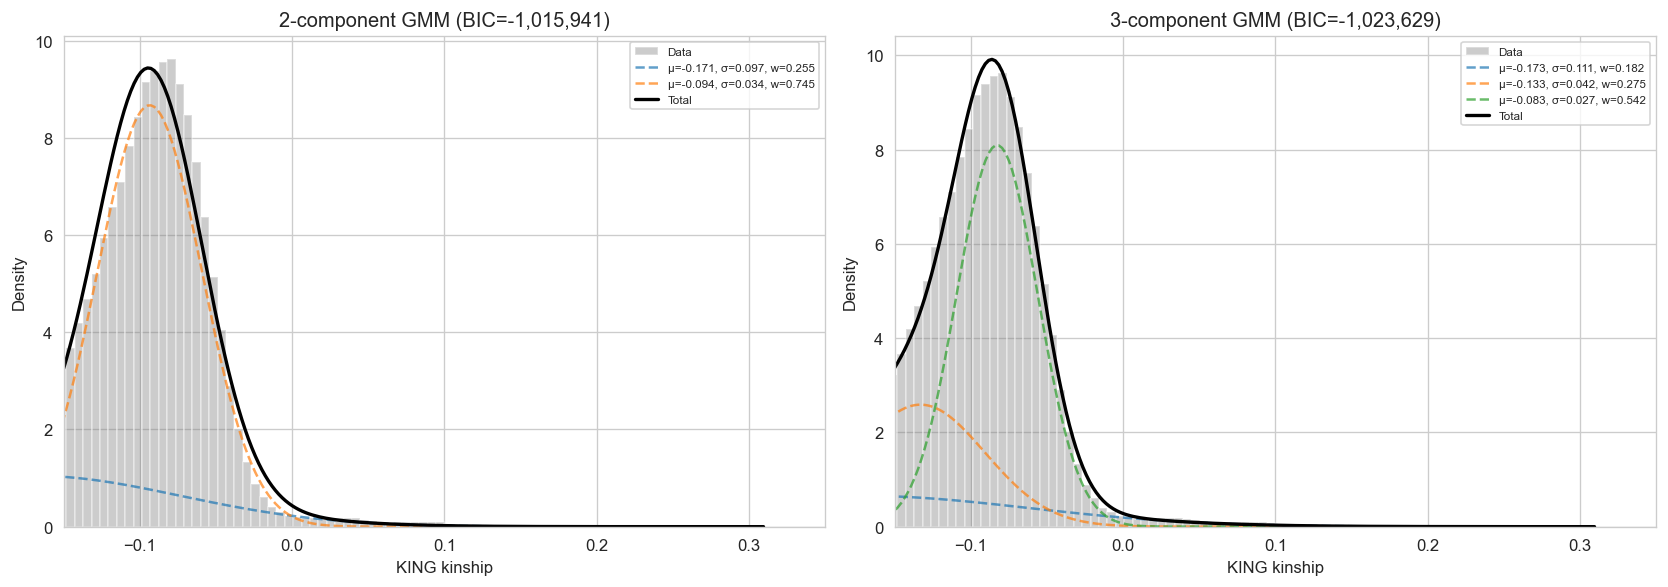

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_grid = np.linspace(kin_valid.min(), kin_valid.max(), 500)

for ax, n_comp in zip(axes, [2, 3]):
    r = results_gmm[n_comp]
    
    ax.hist(kin_valid, bins=200, density=True, alpha=0.4, color='grey', label='Data')
    
    # Total density
    total = np.zeros_like(x_grid)
    for i in range(n_comp):
        comp = r['weights'][i] * norm.pdf(x_grid, r['means'][i], r['stds'][i])
        total += comp
        label = f'μ={r["means"][i]:.3f}, σ={r["stds"][i]:.3f}, w={r["weights"][i]:.3f}'
        ax.plot(x_grid, comp, ls='--', alpha=0.7, label=label)
    
    ax.plot(x_grid, total, 'k-', lw=2, label='Total')
    ax.set_xlabel('KING kinship')
    ax.set_ylabel('Density')
    ax.set_title(f'{n_comp}-component GMM (BIC={r["bic"]:,.0f})')
    ax.legend(fontsize=7)
    ax.set_xlim(-0.15, 0.35)

plt.tight_layout()
plt.savefig('../results/fig_halfsib_mixture.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Use the better GMM to estimate how many 2nd-degree pairs are "real"
best_n = 2 if results_gmm[2]['bic'] < results_gmm[3]['bic'] else 3
print(f'Best model: {best_n}-component GMM (lower BIC)')

best = results_gmm[best_n]
gmm = best['gmm']

# For each pair in the 2nd-degree range, compute posterior probability of belonging
# to the non-background component(s)
second_deg = kin_pairs[kin_pairs['relationship'] == '2nd'].copy()
if len(second_deg) > 0:
    probs = gmm.predict_proba(second_deg['kinship'].values.reshape(-1, 1))
    
    # The background component is the one with the lowest mean
    order = np.argsort(gmm.means_.flatten())
    bg_idx = order[0]
    
    second_deg['p_background'] = probs[:, bg_idx]
    second_deg['p_kin'] = 1 - probs[:, bg_idx]
    
    n_likely_real = (second_deg['p_kin'] > 0.5).sum()
    n_likely_bg = (second_deg['p_kin'] <= 0.5).sum()
    expected_real = second_deg['p_kin'].sum()
    
    print(f'\n2nd-degree pairs (n={len(second_deg)}):')
    print(f'  Likely real kin (p_kin > 0.5): {n_likely_real}')
    print(f'  Likely background (p_kin <= 0.5): {n_likely_bg}')
    print(f'  Expected real kin (sum of p_kin): {expected_real:.0f}')
    print(f'  Mean p_kin: {second_deg["p_kin"].mean():.3f}')

Best model: 3-component GMM (lower BIC)

2nd-degree pairs (n=607):
  Likely real kin (p_kin > 0.5): 0
  Likely background (p_kin <= 0.5): 607
  Expected real kin (sum of p_kin): 0
  Mean p_kin: 0.000


## 3. Network analysis — family cliques

If 2nd-degree pairs are real half-siblings, they should form family clusters:
a single mother's offspring would form a clique of HS pairs.

In [9]:
# Build adjacency for 2nd-degree and closer pairs
close_pairs = kin_pairs[kin_pairs['relationship'].isin(['FS', '2nd'])].copy()

# Count how many times each sample appears in kin pairs
sample_counts = Counter(close_pairs['sample_1'].tolist() + close_pairs['sample_2'].tolist())
top_connected = sample_counts.most_common(20)

print(f'Samples involved in FS + 2nd-degree pairs: {len(sample_counts)}')
print(f'\nMost connected samples (potential family hubs):')
print(f'{"Sample":<20} {"# kin connections":<20} {"Sex":<10} {"Plate":<8} {"Household"}')
for sample, count in top_connected:
    row = meta[meta['sample_id'] == sample].iloc[0] if sample in meta['sample_id'].values else None
    if row is not None:
        print(f'{sample:<20} {count:<20} {str(row.get("mosquito_sex", "?")):<10} '
              f'{str(row.get("plate", "?")):<8} {str(row.get("household_id", "?"))}')
    else:
        print(f'{sample:<20} {count:<20}')

Samples involved in FS + 2nd-degree pairs: 470

Most connected samples (potential family hubs):
Sample               # kin connections    Sex        Plate    Household
ep0000917567         465                  male       4.0      S3-3-4-IN
ep0000915794         131                  male       1.0      C2-1-4
ep0000915627         8                    female     5.0      A1-5-1-in 
ep0000919824         8                    female     5.0      A1-5-5-In
ep0000915630         6                    female     2.0      V1-3-5-in
ep0000915142         5                    female     4.0      S3-4-3-Out
ep0000915321         4                    male       5.0      A1-6-3-Out
ep0000911912         4                    female     5.0      A1-5-1-in 
ep0000843043         3                    male       2.0      A1-3-2 IN
ep0000916899         3                    female     4.0      A1-3-4 IN
ep0000917698         2                    male       1.0      S3-1-7
ep0000915423         2                    

In [10]:
# Find connected components (families) using union-find
parent = {}

def find(x):
    if x not in parent:
        parent[x] = x
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[rx] = ry

for _, row in close_pairs.iterrows():
    union(row['sample_1'], row['sample_2'])

# Group by component
components = {}
for s in parent:
    root = find(s)
    components.setdefault(root, []).append(s)

# Sort by size
families = sorted(components.values(), key=len, reverse=True)

print(f'Connected components (putative family groups): {len(families)}')
print(f'\nLargest families:')
for i, fam in enumerate(families[:10]):
    # Count internal edges
    fam_set = set(fam)
    n_edges = len(close_pairs[
        close_pairs['sample_1'].isin(fam_set) & close_pairs['sample_2'].isin(fam_set)
    ])
    max_edges = len(fam) * (len(fam) - 1) // 2
    density = n_edges / max_edges if max_edges > 0 else 0
    print(f'  Family {i+1}: {len(fam)} members, {n_edges} edges (density={density:.2f})')

Connected components (putative family groups): 1

Largest families:
  Family 1: 470 members, 611 edges (density=0.01)


In [11]:
# Inspect the largest family in detail
if families:
    largest = families[0]
    largest_set = set(largest)
    fam_pairs = close_pairs[
        close_pairs['sample_1'].isin(largest_set) & close_pairs['sample_2'].isin(largest_set)
    ].sort_values('kinship', ascending=False)
    
    print(f'Largest family: {len(largest)} members')
    
    # Member metadata
    print(f'\nMembers:')
    for s in largest:
        row = meta[meta['sample_id'] == s]
        if len(row) > 0:
            r = row.iloc[0]
            print(f'  {s}: sex={r.get("mosquito_sex", "?")}, plate={r.get("plate", "?")}, '
                  f'household={r.get("household_id", "?")}, date={str(r.get("date_collected", "?"))[:10]}')
    
    # Kinship matrix within family
    fam_ids = sorted(largest)
    fam_idx = [sample_ids.index(s) for s in fam_ids if s in sample_ids]
    fam_kin = kinship_full[np.ix_(fam_idx, fam_idx)]
    
    print(f'\nWithin-family kinship matrix:')
    fam_kin_df = pd.DataFrame(fam_kin, index=[sample_ids[i][-6:] for i in fam_idx],
                              columns=[sample_ids[i][-6:] for i in fam_idx])
    print(fam_kin_df.round(3).to_string())

Largest family: 470 members

Members:
  ep0000917698: sex=male, plate=1.0, household=S3-1-7, date=2025-02-25
  ep0000915794: sex=male, plate=1.0, household=C2-1-4, date=2025-02-25
  ep0000915423: sex=male, plate=3.0, household=A1-5-4-In, date=2025-03-04
  ep0000916899: sex=female, plate=4.0, household=A1-3-4 IN, date=2025-02-27
  ep0000915627: sex=female, plate=5.0, household=A1-5-1-in , date=2025-03-04
  ep0000919824: sex=female, plate=5.0, household=A1-5-5-In, date=2025-03-04
  ep0000917567: sex=male, plate=4.0, household=S3-3-4-IN, date=2025-02-27
  ep0000915332: sex=female, plate=5.0, household=S3-6-2-In, date=2025-03-05
  ep0000914830: sex=male, plate=5.0, household=C2-6-1-in, date=2025-03-05
  ep0000915630: sex=female, plate=2.0, household=V1-3-5-in, date=2025-02-27
  ep0000918234: sex=female, plate=4.0, household=A1-3-4 IN, date=2025-02-27
  ep0000915321: sex=male, plate=5.0, household=A1-6-3-Out, date=2025-03-05
  ep0000915142: sex=female, plate=4.0, household=S3-4-3-Out, date=

  ep0000909579: sex=female, plate=4.0, household=J2-3-3, date=2025-02-27
  ep0000842849: sex=male, plate=7.0, household=J2-9-1-In, date=2025-03-11
  ep0000844456: sex=female, plate=7.0, household=S3-9-1-In, date=2025-03-11
  ep0000844027: sex=female, plate=8.0, household=S3-8-4-In, date=2025-03-07
  ep0000919546: sex=female, plate=5.0, household=C2-6-5-In, date=2025-03-05
  ep0000916384: sex=female, plate=7.0, household=C2-7-5-In, date=2025-03-06
  ep0000909337: sex=female, plate=4.0, household=S3-4-1-In, date=2025-02-28
  ep0000845906: sex=female, plate=6.0, household=A1-10-4-in, date=2025-03-12
  ep0000918874: sex=female, plate=5.0, household=S3-6-2-In, date=2025-03-05
  ep0000908218: sex=female, plate=2.0, household=A1-3-4 IN, date=2025-02-27
  ep0000915689: sex=male, plate=1.0, household=C2-1-4, date=2025-02-25
  ep0000842712: sex=female, plate=6.0, household=S3-10-1-In, date=2025-03-12
  ep0000842889: sex=female, plate=4.0, household=S3-4-1-In, date=2025-02-28
  ep0000847112: sex=

  ep0000911382: sex=female, plate=2.0, household=A1-34-Out, date=2025-02-27
  ep0000845667: sex=male, plate=1.0, household=S3-1-6, date=2025-02-25
  ep0000916489: sex=female, plate=3.0, household=A1-5-1-in , date=2025-03-04
  ep0000918813: sex=male, plate=5.0, household=S3-6-1-in, date=2025-03-05
  ep0000915618: sex=female, plate=5.0, household=A1-6-3-Out, date=2025-03-05
  ep0000845887: sex=female, plate=7.0, household=S3-9-1-In, date=2025-03-11
  ep0000916666: sex=female, plate=1.0, household=S3-2-1-In, date=2025-02-26
  ep0000844213: sex=female, plate=7.0, household=C2-9-3-in, date=2025-03-11
  ep0000915055: sex=female, plate=2.0, household=J2-3-3, date=2025-02-27
  ep0000915225: sex=female, plate=2.0, household=A1-2-1-in, date=2025-02-26
  ep0000916822: sex=male, plate=1.0, household=C2-1-4, date=2025-02-25
  ep0000844165: sex=female, plate=8.0, household=S3-7-5-In, date=2025-03-06
  ep0000914952: sex=male, plate=5.0, household=A1-6-1-In, date=2025-03-05
  ep0000915235: sex=female,

  ep0000843063: sex=male, plate=10.0, household=S1-8-4-In, date=2025-03-07
  ep0000920351: sex=female, plate=7.0, household=C2-7-2-In, date=2025-03-06
  ep0000914882: sex=female, plate=8.0, household=S3-7-2-In, date=2025-03-06
  ep0000914835: sex=male, plate=4.0, household=S3-3-1-IN, date=2025-02-27
  ep0000922038: sex=male, plate=5.0, household=A1-6-3-Out, date=2025-03-05
  ep0000843559: sex=female, plate=10.0, household=C3-8-3-In, date=2025-03-07
  ep0000923964: sex=female, plate=8.0, household=J2-7-1-Out, date=2025-03-06
  ep0000915644: sex=female, plate=1.0, household=S3-2-1-In, date=2025-02-26
  ep0000844099: sex=female, plate=4.0, household=V1-4-1-In, date=2025-02-28
  ep0000844139: sex=female, plate=7.0, household=C2-9-3-in, date=2025-03-11
  ep0000914926: sex=female, plate=4.0, household=A1-3-4 IN, date=2025-02-27
  ep0000921184: sex=female, plate=5.0, household=C2-6-4-In, date=2025-03-05
  ep0000915165: sex=female, plate=8.0, household=C2-7-2-In, date=2025-03-06
  ep0000843553

  ep0000845382: sex=female, plate=6.0, household=A1-10-6-In, date=2025-03-12
  ep0000915498: sex=female, plate=4.0, household=V1-3-5-in, date=2025-02-27
  ep0000846242: sex=male, plate=9.0, household=C3-8-3-In, date=2025-03-07
  ep0000915264: sex=male, plate=2.0, household=C2-3-4-IN, date=2025-02-27
  ep0000843513: sex=male, plate=4.0, household=A1-3-4 IN, date=2025-02-27
  ep0000844558: sex=female, plate=1.0, household=C2-2-1-in, date=2025-02-26
  ep0000843959: sex=female, plate=6.0, household=A1-10-6-In, date=2025-03-12
  ep0000914963: sex=male, plate=8.0, household=A1-7-5-in, date=2025-03-06
  ep0000920290: sex=female, plate=6.0, household=S3-6-4-in, date=2025-03-05
  ep0000845416: sex=female, plate=6.0, household=C2-10-1-in, date=2025-03-12
  ep0000922243: sex=female, plate=1.0, household=C2-2-1-in, date=2025-02-26
  ep0000844170: sex=female, plate=6.0, household=A1-10-4-in, date=2025-03-12
  ep0000845727: sex=female, plate=9.0, household=C2-8-4-Out, date=2025-03-07
  ep0000844328:

        841390  841890  841894  841970  842002  842015  842059  842089  842199  842343  842373  842425  842432  842443  842486  842609  842648  842654  842702  842712  842752  842816  842849  842889  842933  842946  842975  842992  843005  843043  843063  843160  843205  843213  843223  843260  843268  843335  843367  843382  843504  843513  843517  843528  843553  843559  843573  843634  843643  843658  843671  843708  843742  843763  843764  843777  843874  843879  843883  843890  843894  843897  843952  843957  843959  843964  843984  843989  844027  844029  844032  844037  844052  844099  844108  844124  844139  844158  844162  844165  844170  844183  844204  844207  844213  844238  844257  844270  844286  844298  844313  844321  844324  844328  844332  844345  844360  844363  844369  844375  844381  844388  844390  844395  844398  844419  844443  844456  844472  844473  844474  844478  844483  844491  844494  844501  844516  844518  844519  844526  844539  844543  844558  844569  

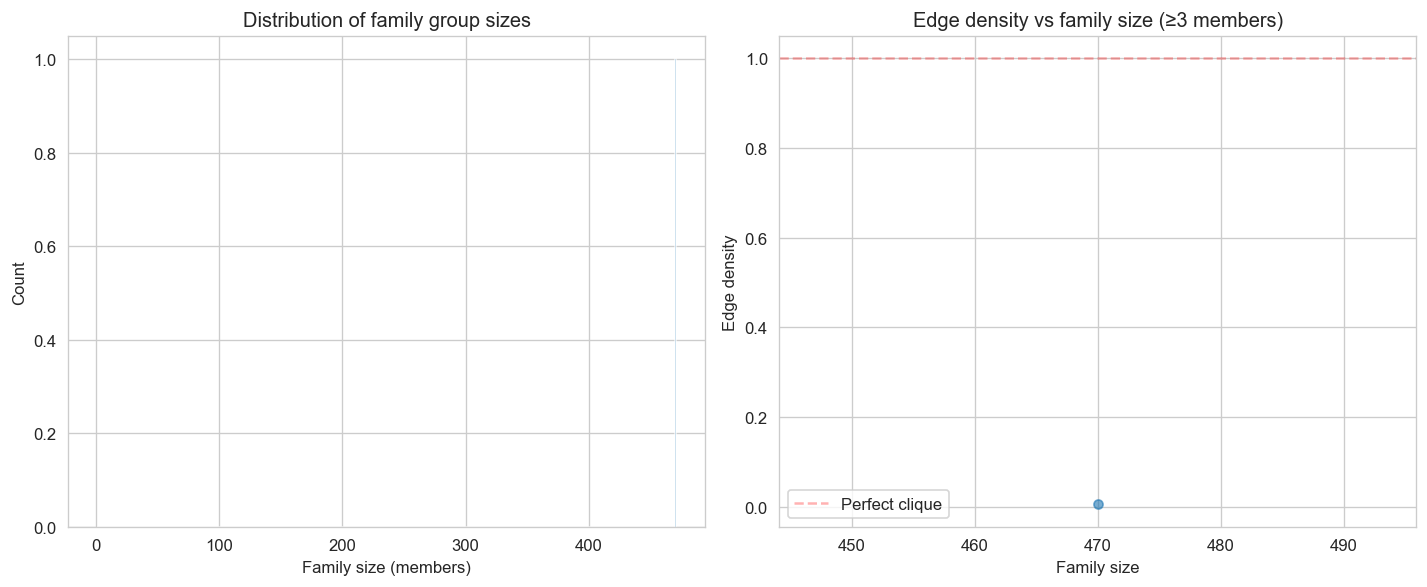

In [12]:
# Clique density analysis: real HS families should have high edge density
# (if 5 members are all half-siblings, we expect C(5,2)=10 edges)

sizes = [len(f) for f in families]
densities = []
for fam in families:
    fam_set = set(fam)
    n_edges = len(close_pairs[
        close_pairs['sample_1'].isin(fam_set) & close_pairs['sample_2'].isin(fam_set)
    ])
    max_edges = len(fam) * (len(fam) - 1) // 2
    densities.append(n_edges / max_edges if max_edges > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(sizes, bins=range(1, max(sizes) + 2), edgecolor='white', alpha=0.7)
ax.set_xlabel('Family size (members)')
ax.set_ylabel('Count')
ax.set_title('Distribution of family group sizes')

ax = axes[1]
multi = [(s, d) for s, d in zip(sizes, densities) if s >= 3]
if multi:
    ax.scatter([s for s, _ in multi], [d for _, d in multi], s=30, alpha=0.6)
    ax.set_xlabel('Family size')
    ax.set_ylabel('Edge density')
    ax.set_title('Edge density vs family size (≥3 members)')
    ax.axhline(1.0, color='red', ls='--', alpha=0.3, label='Perfect clique')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No families with ≥3 members', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../results/fig_halfsib_networks.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. HS-CKMR population estimate

In [13]:
# HS-CKMR: use the estimated number of real HS pairs
# For a population of N breeding adults with Poisson reproductive variance,
# the expected number of half-sibling pairs in a sample of n is:
#   E[k_HS] = n*(n-1) / (4*N)  (for each sex contributing)
#
# This assumes half-siblings share exactly one parent.
# With both maternal and paternal HS combined:
#   E[k_HS] = n*(n-1) / (2*N_f) + n*(n-1) / (2*N_m)
# For equal sex ratio: E[k_HS] = n*(n-1) / N

n = 836  # genotyped samples

# Method 1: Use all 607 2nd-degree pairs as HS
k_hs_all = len(kin_pairs[kin_pairs['relationship'] == '2nd'])

# Method 2: Use expected real count from mixture model
k_hs_expected = expected_real if 'expected_real' in dir() else k_hs_all

# Method 3: Use only pairs with p_kin > 0.5
k_hs_confident = n_likely_real if 'n_likely_real' in dir() else k_hs_all

print('HS-CKMR estimates (N = n*(n-1) / k_HS):')
print(f'  All 2nd-degree pairs (k={k_hs_all}):     N = {n*(n-1) / k_hs_all:,.0f}')
print(f'  GMM expected real (k={k_hs_expected:.0f}):      N = {n*(n-1) / k_hs_expected:,.0f}')
print(f'  Confident (p_kin>0.5) (k={k_hs_confident}):   N = {n*(n-1) / k_hs_confident:,.0f}')

# Compare to FS estimate
k_fs = len(kin_pairs[kin_pairs['relationship'] == 'FS'])
N_fs = n * (n - 1) / (2 * k_fs) if k_fs > 0 else np.nan
print(f'\nFS-CKMR estimate (k={k_fs}):                N = {N_fs:,.0f}')

HS-CKMR estimates (N = n*(n-1) / k_HS):
  All 2nd-degree pairs (k=607):     N = 1,150
  GMM expected real (k=0):      N = 35,513,076
  Confident (p_kin>0.5) (k=0):   N = inf

FS-CKMR estimate (k=4):                N = 87,258


/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_86833/998354852.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'  Confident (p_kin>0.5) (k={k_hs_confident}):   N = {n*(n-1) / k_hs_confident:,.0f}')


In [14]:
# Bootstrap CIs for the HS estimates
def bootstrap_hs_ckmr(n, k_hs, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    N_hat = n * (n - 1) / k_hs
    lam = k_hs  # Poisson rate
    
    boot_Ns = []
    for _ in range(n_boot):
        k = rng.poisson(lam)
        if k > 0:
            boot_Ns.append(n * (n - 1) / k)
    
    boot_Ns = np.array(boot_Ns)
    return N_hat, np.percentile(boot_Ns, 2.5), np.percentile(boot_Ns, 97.5), boot_Ns

estimates = []

# FS estimate
if k_fs > 0:
    N_fs, lo_fs, hi_fs, _ = bootstrap_hs_ckmr(n, k_fs * 2, n_boot=10000)  # *2 because FS formula has /2
    # Recompute properly
    N_fs = n * (n - 1) / (2 * k_fs)
    rng = np.random.default_rng(42)
    boot_fs = [n*(n-1)/(2*k) for k in rng.poisson(k_fs, 10000) if k > 0]
    lo_fs, hi_fs = np.percentile(boot_fs, [2.5, 97.5])
    estimates.append({'method': 'FS (k=4)', 'k': k_fs, 'N_hat': N_fs, 'ci_lo': lo_fs, 'ci_hi': hi_fs})

# HS estimate (all)
N_hs_all, lo_all, hi_all, _ = bootstrap_hs_ckmr(n, k_hs_all)
estimates.append({'method': f'HS all (k={k_hs_all})', 'k': k_hs_all, 'N_hat': N_hs_all, 'ci_lo': lo_all, 'ci_hi': hi_all})

# HS estimate (GMM-corrected)
if k_hs_expected > 0:
    N_hs_gmm, lo_gmm, hi_gmm, _ = bootstrap_hs_ckmr(n, k_hs_expected)
    estimates.append({'method': f'HS GMM (k={k_hs_expected:.0f})', 'k': round(k_hs_expected), 
                      'N_hat': N_hs_gmm, 'ci_lo': lo_gmm, 'ci_hi': hi_gmm})

est_df = pd.DataFrame(estimates)
print('Population size estimates with bootstrap 95% CIs:')
print(est_df.to_string(index=False))

Population size estimates with bootstrap 95% CIs:
        method   k        N_hat         ci_lo         ci_hi
      FS (k=4)   4 8.725750e+04  43628.750000 349030.000000
HS all (k=607) 607 1.150016e+03   1064.115854   1246.591463
  HS GMM (k=0)   0 3.551308e+07 645705.500000 698060.000000


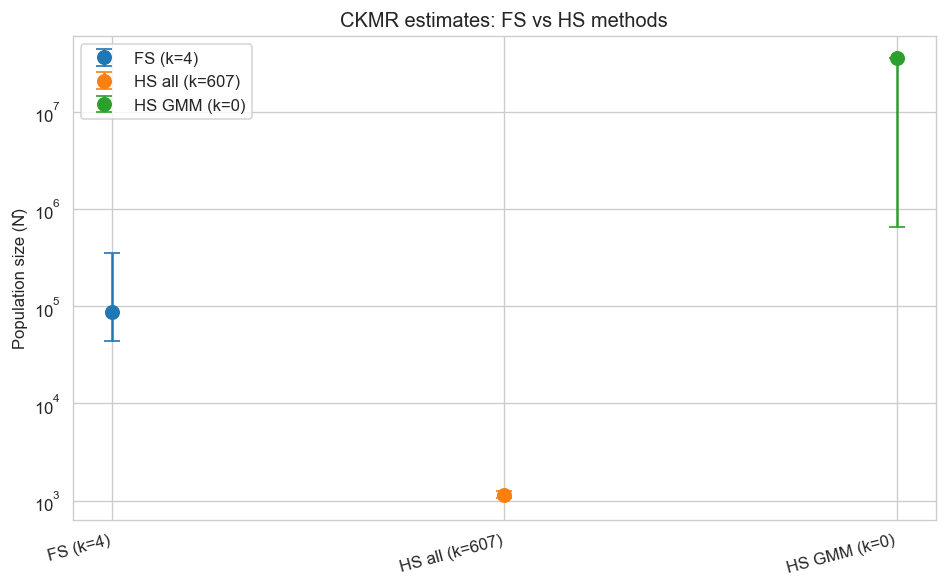

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, row in est_df.iterrows():
    lo_err = max(0, row['N_hat'] - row['ci_lo'])
    hi_err = max(0, row['ci_hi'] - row['N_hat'])
    ax.errorbar(i, row['N_hat'], 
                yerr=[[lo_err], [hi_err]],
                fmt='o', capsize=5, markersize=8, label=row['method'])

ax.set_xticks(range(len(est_df)))
ax.set_xticklabels(est_df['method'], rotation=15, ha='right')
ax.set_ylabel('Population size (N̂)')
ax.set_title('CKMR estimates: FS vs HS methods')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.savefig('../results/fig_halfsib_ckmr.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [16]:
# Save results
est_df.to_csv('../results/halfsib_analysis.csv', index=False)
print('Saved: results/halfsib_analysis.csv')

print('\n=== Half-Sibling Analysis Summary ===')
print(f'2nd-degree pairs found: {k_hs_all}')
if 'n_likely_real' in dir():
    print(f'GMM-estimated real HS: {expected_real:.0f} ({expected_real/k_hs_all*100:.0f}%)')
print(f'Family groups (connected components): {len(families)}')
print(f'Largest family: {len(families[0])} members')
print(f'\nPopulation estimates:')
for _, row in est_df.iterrows():
    print(f'  {row["method"]}: N̂ = {row["N_hat"]:,.0f} (CI: {row["ci_lo"]:,.0f}–{row["ci_hi"]:,.0f})')

Saved: results/halfsib_analysis.csv

=== Half-Sibling Analysis Summary ===
2nd-degree pairs found: 607
GMM-estimated real HS: 0 (0%)
Family groups (connected components): 1
Largest family: 470 members

Population estimates:
  FS (k=4): N̂ = 87,258 (CI: 43,629–349,030)
  HS all (k=607): N̂ = 1,150 (CI: 1,064–1,247)
  HS GMM (k=0): N̂ = 35,513,076 (CI: 645,706–698,060)
